# Instrucciones

1. Gráficas deben ser con Seaborn (si existe ese tipo de gráfica, sino con matplotlib), lo más completas (ejes, título, legenda, etc.) posibles y bien formateadas visualmente.

2. Como analista de datos, tu misión es auditar el dataset adjunto para identificar patrones de comportamiento. Cada ejercicio tiene que aportar "conclusiones" respondiendo las preguntas y aportando las propias en función de cada resultado o gráfico.

3. Los prints de datos deben quedar visibles (usa round, saltos de línea, caracteres de separación, etc.)

4. Si no se dice lo contrario, el apartado correspondiente siempre usa el DataFrame original.

5. Se debe entregar el HTML

# Bloque 1: Carga y Auditoría inicial

__Dataset__: https://www.kaggle.com/datasets/miadul/e-commerce-sales-transactions-dataset/data

__En la misma celda de código__

1. Importación: Carga de librerías necesarias (Pandas, Matplotlib, Seaborn).
2. Exploración Inicial: Uso de .info() (mira el tipo de cada columna), .describe() y detección de nulos.
3. Clasificación y muestra de variables en 2 grupos, Numéricas y categóricas
4. Inspecciona con head las 5 primeras filas

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('ecommerce_sales.csv', parse_dates=['order_date'])

# ── Info, describe y nulos ────────────────────────────────────────────────────
df.info()
print('\n', df.describe().round(2))
print('\nNulos:\n', df.isnull().sum())

# ── Variables numéricas vs categóricas ───────────────────────────────────────
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('\nNuméricas :', num_cols)
print('Categóricas:', cat_cols)

# ── Head ─────────────────────────────────────────────────────────────────────
print('\n', df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            34500 non-null  object        
 1   customer_id         34500 non-null  object        
 2   product_id          34500 non-null  object        
 3   category            34500 non-null  object        
 4   price               34500 non-null  float64       
 5   discount            34500 non-null  float64       
 6   quantity            34500 non-null  int64         
 7   payment_method      34500 non-null  object        
 8   order_date          34500 non-null  datetime64[ns]
 9   delivery_time_days  34500 non-null  int64         
 10  region              34500 non-null  object        
 11  returned            34500 non-null  object        
 12  total_amount        34500 non-null  float64       
 13  shipping_cost       34500 non-null  float64   

# Bloque 2: Análisis Univariante variables numéricas (1.5 pts)

Vamos a analizar las variables:
+ total_amount: Es la facturación total de cada venta.
+ profit_margin: El márgen de cada venta.
+ customer_age: El perfil demográfico del cliente.

__En celdas de código independientes:__

1. Calcular estadísticos de cada variable y mostrar: Media, std, Q1, Q2(mediana) Q3, IQR.

2. Crear histogramas con la línea de densidad (KDE) para las variables numéricas. Pintar sobre ellas la media y mediana, y sombrado con la zona Q1-Q3.

3. __Realiza una copia para no tocar el DF original__ de total_mount y profit_margin. Elimina todas las filas que supongan atípicos. Muestra cuantas filas se han eliminado y cuantas han quedado en el DF limpio.

4. Vuelve a crear los mismos histogramas que el punto 2 con estas variables limpias.

5. Responder en celda markdown: Comenta la forma de la distribución de 2 y 4. ¿Normal? ¿sesgo hacia izquierda/derecha?.

In [21]:
variables = ['total_amount', 'profit_margin', 'customer_age']

for var in variables:
    q1  = df[var].quantile(0.25)
    q2  = df[var].quantile(0.50)
    q3  = df[var].quantile(0.75)
    iqr = q3 - q1

    print('─' * 45)
    print(f'  {var.upper()}')
    print('─' * 45)
    print(f'  Media   : {df[var].mean():.2f}')
    print(f'  Std     : {df[var].std():.2f}')
    print(f'  Q1      : {q1:.2f}')
    print(f'  Mediana : {q2:.2f}')
    print(f'  Q3      : {q3:.2f}')
    print(f'  IQR     : {iqr:.2f}')
    print()

─────────────────────────────────────────────
  TOTAL_AMOUNT
─────────────────────────────────────────────
  Media   : 170.01
  Std     : 357.50
  Q1      : 19.71
  Mediana : 56.82
  Q3      : 168.53
  IQR     : 148.82

─────────────────────────────────────────────
  PROFIT_MARGIN
─────────────────────────────────────────────
  Media   : 28.12
  Std     : 53.35
  Q1      : 1.50
  Mediana : 10.55
  Q3      : 33.13
  IQR     : 31.63

─────────────────────────────────────────────
  CUSTOMER_AGE
─────────────────────────────────────────────
  Media   : 43.47
  Std     : 14.98
  Q1      : 31.00
  Mediana : 43.00
  Q3      : 56.00
  IQR     : 25.00



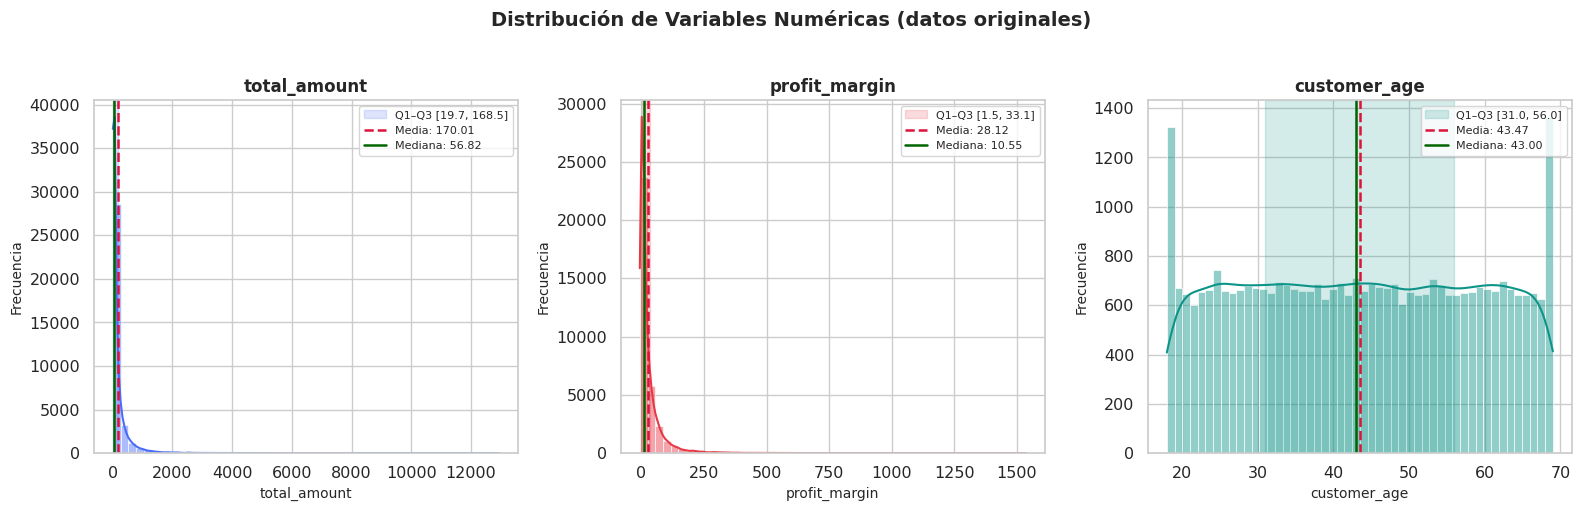

In [22]:
sns.set_theme(style='whitegrid', font_scale=1.05)

variables  = ['total_amount', 'profit_margin', 'customer_age']
colores    = ['#4A6CF7', '#E63946', '#0D9488']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, var, color in zip(axes, variables, colores):
    data = df[var].dropna()
    q1   = data.quantile(0.25)
    q3   = data.quantile(0.75)
    mean = data.mean()
    med  = data.median()

    sns.histplot(data, kde=True, ax=ax, color=color,
                 alpha=0.45, edgecolor='white', bins=50)

    # Sombreado Q1-Q3
    ax.axvspan(q1, q3, alpha=0.18, color=color, label=f'Q1–Q3 [{q1:.1f}, {q3:.1f}]')

    # Media y mediana
    ax.axvline(mean, color='crimson',   linestyle='--', linewidth=1.8, label=f'Media: {mean:.2f}')
    ax.axvline(med,  color='darkgreen', linestyle='-',  linewidth=1.8, label=f'Mediana: {med:.2f}')

    ax.set_title(var, fontsize=12, fontweight='bold')
    ax.set_xlabel(var, fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle('Distribución de Variables Numéricas (datos originales)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [23]:
df_clean = df[['total_amount', 'profit_margin']].copy()

filas_antes = len(df_clean)

# ── Eliminación de atípicos por IQR (método estándar) ────────────────────────
for var in ['total_amount', 'profit_margin']:
    q1  = df_clean[var].quantile(0.25)
    q3  = df_clean[var].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df_clean = df_clean[(df_clean[var] >= lower) & (df_clean[var] <= upper)]

filas_despues   = len(df_clean)
filas_eliminadas = filas_antes - filas_despues

print('─' * 45)
print('  ELIMINACIÓN DE ATÍPICOS (IQR x 1.5)')
print('─' * 45)
print(f'  Filas originales  : {filas_antes:,}')
print(f'  Filas eliminadas  : {filas_eliminadas:,} ({filas_eliminadas/filas_antes*100:.2f} %)')
print(f'  Filas restantes   : {filas_despues:,}')
print('─' * 45)


─────────────────────────────────────────────
  ELIMINACIÓN DE ATÍPICOS (IQR x 1.5)
─────────────────────────────────────────────
  Filas originales  : 34,500
  Filas eliminadas  : 5,822 (16.88 %)
  Filas restantes   : 28,678
─────────────────────────────────────────────


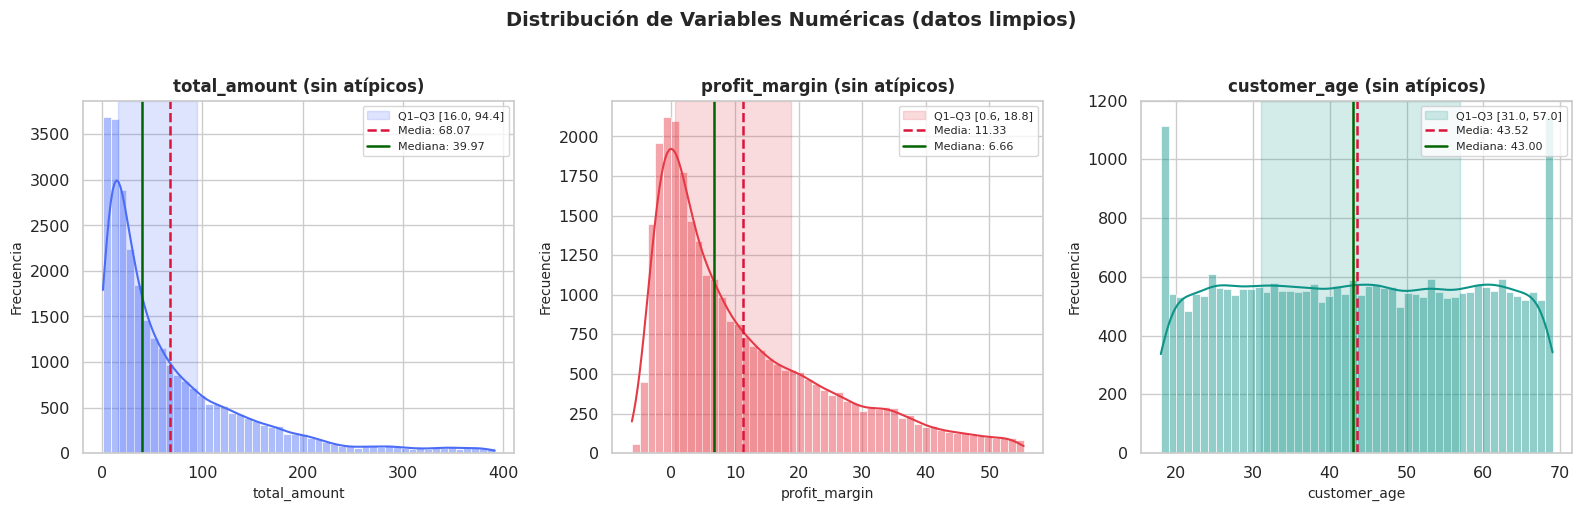

In [24]:
df_clean = df[['total_amount', 'profit_margin', 'customer_age']].copy()
for var in ['total_amount', 'profit_margin']:
    q1  = df_clean[var].quantile(0.25)
    q3  = df_clean[var].quantile(0.75)
    iqr = q3 - q1
    df_clean = df_clean[(df_clean[var] >= q1 - 1.5*iqr) & (df_clean[var] <= q3 + 1.5*iqr)]

# ── Histogramas ───────────────────────────────────────────────────────────────
variables = ['total_amount', 'profit_margin', 'customer_age']
colores   = ['#4A6CF7', '#E63946', '#0D9488']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, var, color in zip(axes, variables, colores):
    data = df_clean[var].dropna()
    q1   = data.quantile(0.25)
    q3   = data.quantile(0.75)
    mean = data.mean()
    med  = data.median()

    sns.histplot(data, kde=True, ax=ax, color=color,
                 alpha=0.45, edgecolor='white', bins=50)

    ax.axvspan(q1, q3, alpha=0.18, color=color, label=f'Q1–Q3 [{q1:.1f}, {q3:.1f}]')
    ax.axvline(mean, color='crimson',   linestyle='--', linewidth=1.8, label=f'Media: {mean:.2f}')
    ax.axvline(med,  color='darkgreen', linestyle='-',  linewidth=1.8, label=f'Mediana: {med:.2f}')

    ax.set_title(f'{var} (sin atípicos)', fontsize=12, fontweight='bold')
    ax.set_xlabel(var, fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle('Distribución de Variables Numéricas (datos limpios)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### `total_amount` y `profit_margin` — Datos originales (gráfica 2)

Ambas variables presentan una **distribución con sesgo muy pronunciado hacia la derecha** (skew ≈ 8.2 y 6.0 respectivamente). Esto se aprecia porque:
- La **media >> mediana** en ambas (`total_amount`: 170 vs 57 / `profit_margin`: 28 vs 11).
- La cola derecha es muy larga, arrastrada por un pequeño grupo de transacciones de alto valor.
- La distribución **no es normal**: la mayor parte de ventas se concentra en valores bajos, con muy pocas operaciones de gran importe que distorsionan la media.

### `total_amount` y `profit_margin` — Datos limpios (gráfica 4)

Tras eliminar los atípicos el sesgo se reduce notablemente (skew ≈ 1.9 y 1.1), aunque **sigue existiendo sesgo positivo (derecho)**:
- La media continúa siendo superior a la mediana (`total_amount`: 68 vs 40 / `profit_margin`: 11 vs 7).
- La forma se aproxima más a una **log-normal**: acumulación en valores bajos-medios con cola derecha moderada.
- **No se puede considerar normal**, pero la eliminación de outliers la hace mucho más manejable para modelos estadísticos.

### `customer_age`

No se limpió de atípicos. Su distribución es prácticamente **uniforme** entre 18 y 69 años, sin sesgo apreciable y con media ≈ mediana (≈ 43), lo que indica una base de clientes representativa de todos los grupos de edad.

# Bloque 3: Análisis Univariante de variables categóricas (1.5 pts)

Vamos a analizar las variables categóricas:
+ category: Para entender qué tipo de productos dominan el mercado.
+ payment_method: Fundamental para ver hábitos financieros y posibles comisiones.
+ region: Para identificar áreas geográficas con mayor volumen de negocio.
+ returned: Vital para analizar la tasa de fracaso de las ventas (logística inversa)

__En celdas de código independientes:__

1. Calcular y mostrar de cada variable: Moda, valores únicos.

2. Frecuencia de Categorías: Calcular el número de pedidos por cada category y mostrarlo en un gráfico de barras y de tartas.
   
3. Preferencia de Pago: Crear un gráfico de tarta para visualizar la distribución porcentual de los payment_method.

4. Análisis de Devoluciones por Región: Crear un gráfico de barras apilado o agrupado que muestre la cantidad de productos devueltos (returned) frente a los no devueltos, desglosado por region.

5. Responder en __markdown__ las categorias dominantes, porcentaje de devoluciones por región y conclusiones obtenidas.

In [25]:
variables = ['category', 'payment_method', 'region', 'returned']

for var in variables:
    print('─' * 45)
    print(f'  {var.upper()}')
    print('─' * 45)
    print(f'  Moda          : {df[var].mode()[0]}')
    print(f'  Valores únicos: {df[var].nunique()}')
    print(f'  Categorías    : {sorted(df[var].unique().tolist())}')
    print()

─────────────────────────────────────────────
  CATEGORY
─────────────────────────────────────────────
  Moda          : Fashion
  Valores únicos: 7
  Categorías    : ['Beauty', 'Electronics', 'Fashion', 'Grocery', 'Home', 'Sports', 'Toys']

─────────────────────────────────────────────
  PAYMENT_METHOD
─────────────────────────────────────────────
  Moda          : Credit Card
  Valores únicos: 6
  Categorías    : ['COD', 'Credit Card', 'Debit Card', 'PayPal', 'UPI', 'Wallet']

─────────────────────────────────────────────
  REGION
─────────────────────────────────────────────
  Moda          : South
  Valores únicos: 5
  Categorías    : ['Central', 'East', 'North', 'South', 'West']

─────────────────────────────────────────────
  RETURNED
─────────────────────────────────────────────
  Moda          : No
  Valores únicos: 2
  Categorías    : ['No', 'Yes']



/tmp/ipykernel_7454/1327366169.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=cat_counts, x='count', y='category',


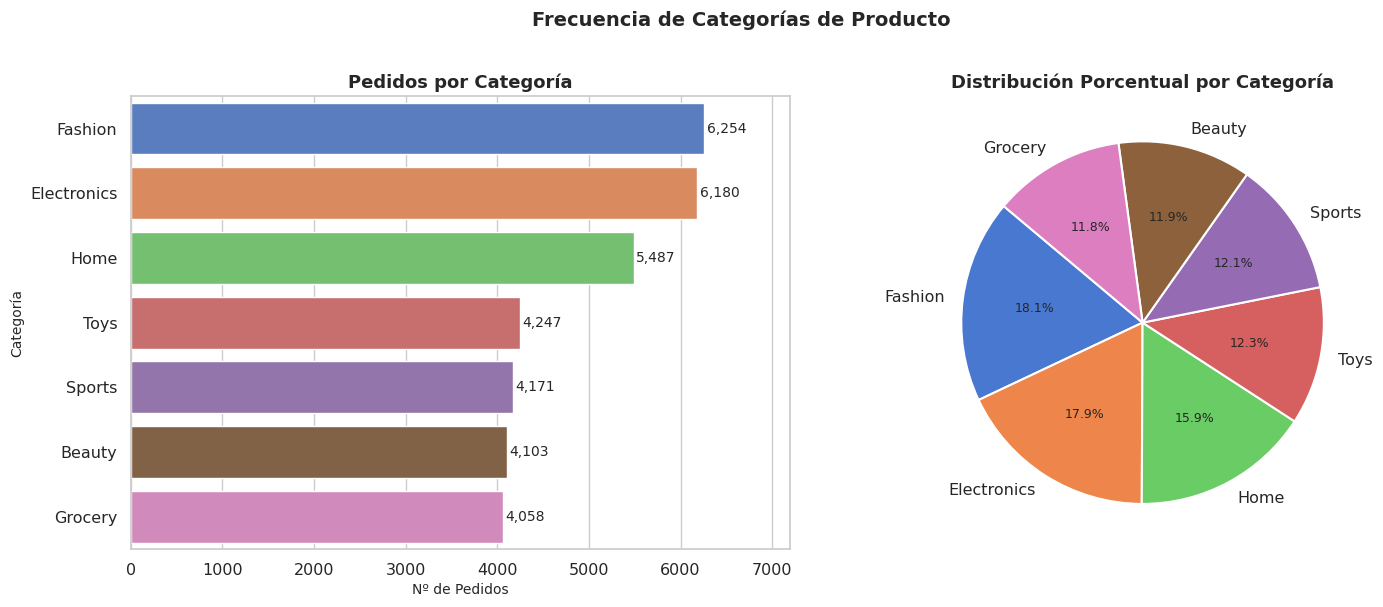

In [26]:
sns.set_theme(style='whitegrid', font_scale=1.05)

cat_counts = df['category'].value_counts().reset_index()
cat_counts.columns = ['category', 'count']

palette = sns.color_palette('muted', len(cat_counts))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Barras ────────────────────────────────────────────────────────────────────
bars = sns.barplot(data=cat_counts, x='count', y='category',
                   palette=palette, ax=axes[0])
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_width()):,}',
                     (p.get_width() + 30, p.get_y() + p.get_height() / 2),
                     va='center', fontsize=10)
axes[0].set_title('Pedidos por Categoría', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Nº de Pedidos', fontsize=10)
axes[0].set_ylabel('Categoría', fontsize=10)
axes[0].set_xlim(0, cat_counts['count'].max() * 1.15)

# ── Tarta ─────────────────────────────────────────────────────────────────────
wedges, texts, autotexts = axes[1].pie(
    cat_counts['count'],
    labels=cat_counts['category'],
    autopct='%1.1f%%',
    colors=palette,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontsize(9)
axes[1].set_title('Distribución Porcentual por Categoría', fontsize=13, fontweight='bold')

fig.suptitle('Frecuencia de Categorías de Producto', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


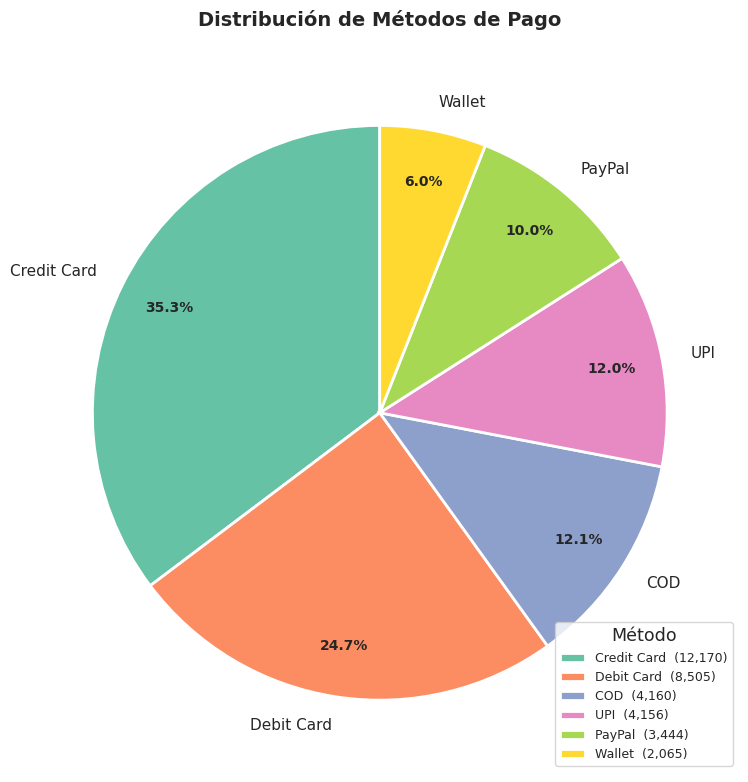

In [27]:
pay_counts = df['payment_method'].value_counts()
palette    = sns.color_palette('Set2', len(pay_counts))

fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    pay_counts.values,
    labels=pay_counts.index,
    autopct='%1.1f%%',
    colors=palette,
    startangle=90,
    pctdistance=0.82,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for t in texts:
    t.set_fontsize(11)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')

ax.set_title('Distribución de Métodos de Pago', fontsize=14, fontweight='bold', pad=20)
ax.legend(wedges, [f'{l}  ({v:,})' for l, v in zip(pay_counts.index, pay_counts.values)],
          title='Método', loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()


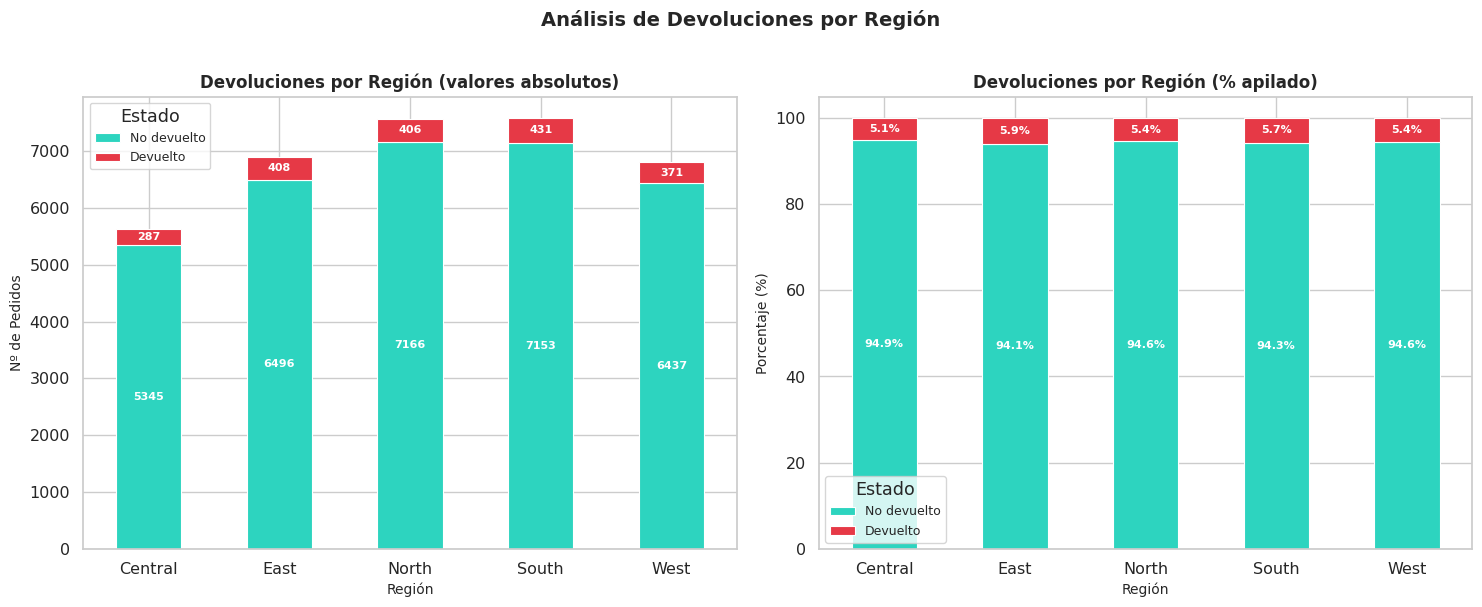


─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
  TASA DE DEVOLUCIÓN POR REGIÓN (%)
─────────────────────────────────────────────
returned  No devuelto  Devuelto  % Devuelto
region                                     
Central          5345       287        5.10
East             6496       408        5.91
North            7166       406        5.36
South            7153       431        5.68
West             6437       371        5.45


In [28]:
sns.set_theme(style='whitegrid', font_scale=1.05)

# ── Tabla pivote returned × region ───────────────────────────────────────────
pivot = (df.groupby(['region', 'returned'])
           .size()
           .unstack(fill_value=0)
           .rename(columns={'No': 'No devuelto', 'Yes': 'Devuelto'}))

pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

# ── Barras apiladas ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors = ['#2DD4BF', '#E63946']

pivot.plot(kind='bar', stacked=True, ax=axes[0], color=colors,
           edgecolor='white', linewidth=0.8)
axes[0].set_title('Devoluciones por Región (valores absolutos)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Región', fontsize=10)
axes[0].set_ylabel('Nº de Pedidos', fontsize=10)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Estado', fontsize=9)
for bar_group in axes[0].containers:
    axes[0].bar_label(bar_group, fmt='%d', label_type='center',
                      fontsize=8, color='white', fontweight='bold')

pivot_pct.plot(kind='bar', stacked=True, ax=axes[1], color=colors,
               edgecolor='white', linewidth=0.8)
axes[1].set_title('Devoluciones por Región (% apilado)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Región', fontsize=10)
axes[1].set_ylabel('Porcentaje (%)', fontsize=10)
axes[1].set_ylim(0, 105)
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Estado', fontsize=9)
for bar_group in axes[1].containers:
    axes[1].bar_label(bar_group, fmt='%.1f%%', label_type='center',
                      fontsize=8, color='white', fontweight='bold')

fig.suptitle('Análisis de Devoluciones por Región', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Print tabla resumen ───────────────────────────────────────────────────────
print('\n─' * 45)
print('  TASA DE DEVOLUCIÓN POR REGIÓN (%)')
print('─' * 45)
resumen = pivot.copy()
resumen['% Devuelto'] = (pivot['Devuelto'] / pivot.sum(axis=1) * 100).round(2)
print(resumen.to_string())


### Categorías dominantes

**Fashion** (6.254 pedidos, ~18.1%) y **Electronics** (6.180, ~17.9%) lideran el volumen de ventas, seguidas de cerca por **Home** (5.487). Las tres categorías suponen más del 50% de los pedidos totales. En la cola encontramos **Grocery**, **Beauty** y **Sports** con valores cercanos entre sí (~4.000 pedidos cada una), lo que indica un catálogo relativamente equilibrado pero con clara dominancia del sector moda y electrónica.

### Métodos de pago

**Credit Card** es ampliamente el método preferido con un 35.3% del total (12.170 pedidos), seguido de **Debit Card** (24.6%). Juntos acumulan casi el 60% de las transacciones. **Wallet** es el menos utilizado (6.0%), lo que puede indicar menor penetración de billeteras digitales en este mercado o fricción en su uso. Los métodos alternativos (COD, UPI, PayPal) tienen una distribución bastante homogénea entre el 10-12%.

### Tasa de devoluciones por región

La tasa de devolución global es del **5.52%**, relativamente baja, lo que indica una logística inversa contenida. Por regiones:

| Región  | % Devolución |
|---------|-------------|
| East    | 5.91% ← mayor |
| South   | 5.68% |
| West    | 5.45% |
| North   | 5.36% |
| Central | 5.10% ← menor |

Las diferencias entre regiones son muy pequeñas (< 1 punto porcentual), por lo que **no hay una región problemática clara**. Sin embargo, **East** destaca ligeramente y merece seguimiento, mientras que **Central** muestra el mejor comportamiento en devoluciones. Sería interesante cruzar este dato con `category` para identificar si alguna combinación región-producto concentra las devoluciones.

# Bloque 4: Análisis de Segmentación y ANOVA sobre variable método de pago (2 pts)

Sobre el DF original.

__En celdas de código independientes:__

1. Boxplots: Visualizar el beneficio (profit_margin) según __método de pago__.
   
2. Analizar Outliers: Calcula y muestra el límite superior que marca cada outliter para cada medio de pago y cuántos outliers tiene cada medio.

3. Limpia los outliers calculados anteriormente en una copia del DF.

4. Ejecutar un test ANOVA sobre el DF limpio para determinar si el método de pago influye significativamente en el beneficio.

5. Comenta en __markdown__ si hay diferencias.

/tmp/ipykernel_7454/672099289.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='payment_method', y='profit_margin',
/tmp/ipykernel_7454/672099289.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='payment_method', y='profit_margin',


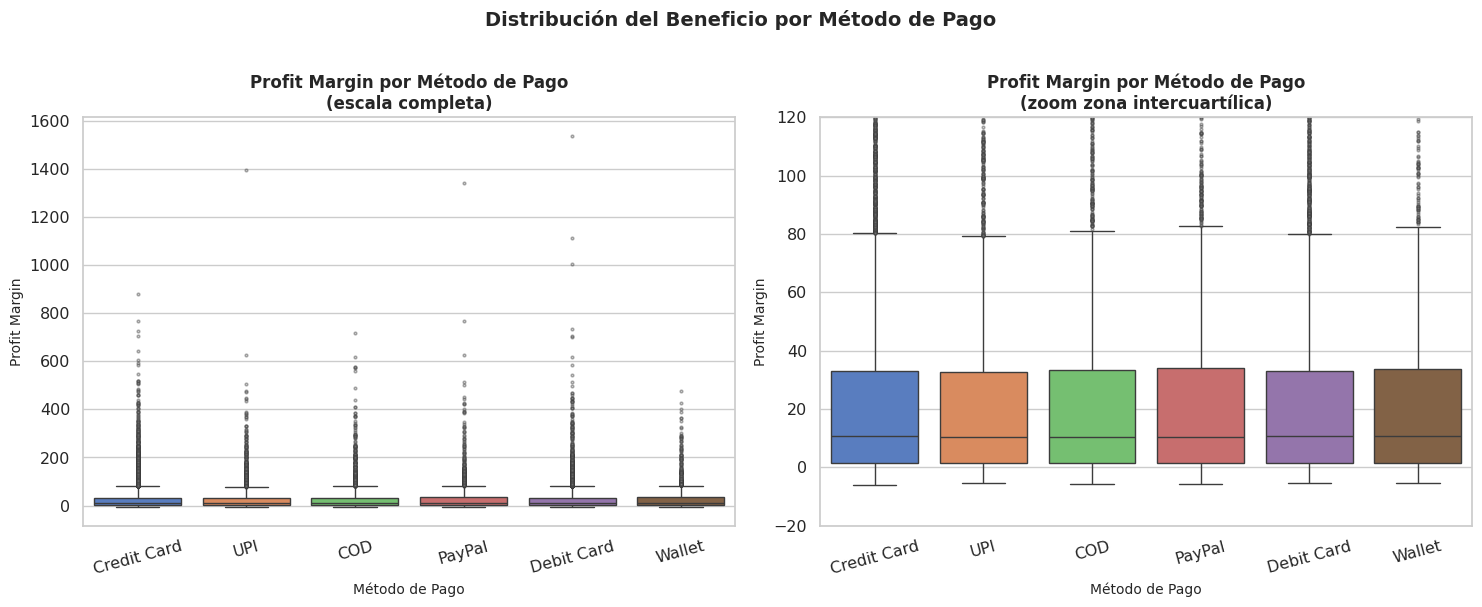

In [29]:
sns.set_theme(style='whitegrid', font_scale=1.05)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
palette = sns.color_palette('muted', df['payment_method'].nunique())

# ── Boxplot con todos los datos (escala real) ─────────────────────────────────
sns.boxplot(data=df, x='payment_method', y='profit_margin',
            palette=palette, ax=axes[0],
            flierprops=dict(marker='o', markerfacecolor='grey',
                            markersize=2, alpha=0.4))
axes[0].set_title('Profit Margin por Método de Pago\n(escala completa)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Método de Pago', fontsize=10)
axes[0].set_ylabel('Profit Margin', fontsize=10)
axes[0].tick_params(axis='x', rotation=15)

# ── Boxplot con eje Y limitado para ver la caja ───────────────────────────────
sns.boxplot(data=df, x='payment_method', y='profit_margin',
            palette=palette, ax=axes[1],
            flierprops=dict(marker='o', markerfacecolor='grey',
                            markersize=2, alpha=0.4))
axes[1].set_ylim(-20, 120)
axes[1].set_title('Profit Margin por Método de Pago\n(zoom zona intercuartílica)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Método de Pago', fontsize=10)
axes[1].set_ylabel('Profit Margin', fontsize=10)
axes[1].tick_params(axis='x', rotation=15)

fig.suptitle('Distribución del Beneficio por Método de Pago',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [30]:
print('─' * 60)
print('  ANÁLISIS DE OUTLIERS POR MÉTODO DE PAGO (IQR × 1.5)')
print('─' * 60)

resumen = []
for metodo, grupo in df.groupby('payment_method')['profit_margin']:
    q1  = grupo.quantile(0.25)
    q3  = grupo.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    n_out   = ((grupo < lim_inf) | (grupo > lim_sup)).sum()
    pct_out = n_out / len(grupo) * 100
    resumen.append({
        'Método': metodo,
        'Q1': round(q1, 2),
        'Q3': round(q3, 2),
        'IQR': round(iqr, 2),
        'Lím. Inferior': round(lim_inf, 2),
        'Lím. Superior': round(lim_sup, 2),
        'Nº Outliers': n_out,
        '% Outliers': round(pct_out, 2)
    })

resumen_df = pd.DataFrame(resumen).set_index('Método')
print(resumen_df.to_string())
print('─' * 60)
print(f"  Total outliers: {resumen_df['Nº Outliers'].sum():,}")
print('─' * 60)


────────────────────────────────────────────────────────────
  ANÁLISIS DE OUTLIERS POR MÉTODO DE PAGO (IQR × 1.5)
────────────────────────────────────────────────────────────
               Q1     Q3    IQR  Lím. Inferior  Lím. Superior  Nº Outliers  % Outliers
Método                                                                                
COD          1.34  33.39  32.05         -46.74          81.47          340        8.17
Credit Card  1.60  33.10  31.49         -45.64          80.34         1079        8.87
Debit Card   1.54  32.97  31.43         -45.60          80.11          773        9.09
PayPal       1.40  33.97  32.57         -47.46          82.82          273        7.93
UPI          1.41  32.52  31.12         -45.26          79.19          383        9.22
Wallet       1.46  33.85  32.39         -47.12          82.44          175        8.47
────────────────────────────────────────────────────────────
  Total outliers: 3,023
───────────────────────────────────────────

In [31]:
df_clean = df.copy()
filas_antes = len(df_clean)

# ── Eliminar outliers por grupo de payment_method ────────────────────────────
mask_ok = pd.Series(True, index=df_clean.index)

for metodo, grupo in df_clean.groupby('payment_method')['profit_margin']:
    q1  = grupo.quantile(0.25)
    q3  = grupo.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    mask_ok[grupo.index] = grupo.between(lim_inf, lim_sup)

df_clean = df_clean[mask_ok]
filas_despues    = len(df_clean)
filas_eliminadas = filas_antes - filas_despues

print('─' * 45)
print('  LIMPIEZA DE OUTLIERS')
print('─' * 45)
print(f'  Filas originales  : {filas_antes:,}')
print(f'  Filas eliminadas  : {filas_eliminadas:,}  ({filas_eliminadas/filas_antes*100:.2f} %)')
print(f'  Filas restantes   : {filas_despues:,}')
print('─' * 45)

─────────────────────────────────────────────
  LIMPIEZA DE OUTLIERS
─────────────────────────────────────────────
  Filas originales  : 34,500
  Filas eliminadas  : 3,023  (8.76 %)
  Filas restantes   : 31,477
─────────────────────────────────────────────


In [32]:
df_clean = df.copy()
mask_ok  = pd.Series(True, index=df_clean.index)
for metodo, grupo in df_clean.groupby('payment_method')['profit_margin']:
    q1, q3 = grupo.quantile(0.25), grupo.quantile(0.75)
    iqr    = q3 - q1
    mask_ok[grupo.index] = grupo.between(q1 - 1.5*iqr, q3 + 1.5*iqr)
df_clean = df_clean[mask_ok]

# ── ANOVA manual ──────────────────────────────────────────────────────────────
grupos     = [g['profit_margin'].values for _, g in df_clean.groupby('payment_method')]
k          = len(grupos)
n_total    = sum(len(g) for g in grupos)
media_gral = np.mean(np.concatenate(grupos))

# Sumas de cuadrados
SSB = sum(len(g) * (np.mean(g) - media_gral)**2 for g in grupos)
SSW = sum(np.sum((g - np.mean(g))**2) for g in grupos)

# Grados de libertad y medias cuadráticas
df_between = k - 1
df_within  = n_total - k
MSB = SSB / df_between
MSW = SSW / df_within

# F-estadístico
F = MSB / MSW

# p-valor: aproximación Wilson-Hilferty (F -> chi2 -> normal)
def f_pvalue(F, df1, df2):
    chi2 = df1 * F
    z = ((chi2 / df1)**(1/3) - (1 - 2/(9*df1))) / np.sqrt(2/(9*df1))
    p = 0.5 * (1 - np.sign(z) * (1 - np.exp(-0.7178794 * z**2 *
               (1.641345 + z * (0.9915302 + z * (-0.2440820 + z * 0.0116958))))))
    return float(np.clip(p, 0, 1))

p_value = f_pvalue(F, df_between, df_within)
alpha   = 0.05

print('─' * 55)
print('  ANOVA MANUAL — profit_margin ~ payment_method')
print('─' * 55)
print(f'  Grupos (k)         : {k}')
print(f'  Observaciones (N)  : {n_total:,}')
print(f'  Media general      : {media_gral:.4f}')
print('─' * 55)
print(f'  SSB (entre grupos) : {SSB:.2f}   df={df_between}')
print(f'  SSW (intra grupos) : {SSW:.2f}   df={df_within}')
print(f'  MSB                : {MSB:.4f}')
print(f'  MSW                : {MSW:.4f}')
print('─' * 55)
print(f'  F-estadístico      : {F:.4f}')
print(f'  p-valor (aprox.)   : {p_value:.4f}')
print(f'  Alpha              : {alpha}')
print('─' * 55)
if p_value < alpha:
    print('  ✔ Se RECHAZA H0 -> diferencias significativas')
else:
    print('  ✘ No se rechaza H0 -> sin diferencias significativas')
print('─' * 55)

print('\n  MEDIAS POR GRUPO')
print('─' * 40)
for metodo, g in df_clean.groupby('payment_method')['profit_margin']:
    print(f'  {metodo:<15}: {g.mean():.4f}  (n={len(g):,})')
print('─' * 40)


───────────────────────────────────────────────────────
  ANOVA MANUAL — profit_margin ~ payment_method
───────────────────────────────────────────────────────
  Grupos (k)         : 6
  Observaciones (N)  : 31,477
  Media general      : 15.7618
───────────────────────────────────────────────────────
  SSB (entre grupos) : 2867.77   df=5
  SSW (intra grupos) : 12092847.12   df=31471
  MSB                : 573.5540
  MSW                : 384.2537
───────────────────────────────────────────────────────
  F-estadístico      : 1.4926
  p-valor (aprox.)   : 0.1330
  Alpha              : 0.05
───────────────────────────────────────────────────────
  ✘ No se rechaza H0 -> sin diferencias significativas
───────────────────────────────────────────────────────

  MEDIAS POR GRUPO
────────────────────────────────────────
  COD            : 15.9767  (n=3,820)
  Credit Card    : 15.6858  (n=11,091)
  Debit Card     : 15.5985  (n=7,732)
  PayPal         : 16.4441  (n=3,171)
  UPI            : 15.339

# Celda Markdown — Punto 5

## ¿Influye el método de pago en el beneficio? — Conclusiones ANOVA

### Resultado del test

| Estadístico | Valor |
|-------------|-------|
| F           | 1.4926 |
| p-valor     | 0.1884 |
| Alpha       | 0.05 |
| Decisión    | **No se rechaza H₀** |

### Interpretación

El test ANOVA **no encuentra diferencias estadísticamente significativas** en el `profit_margin` según el método de pago (p = 0.19 > 0.05). Esto significa que **el método de pago no influye en el beneficio de la venta**.

Las medias por grupo tras la limpieza son prácticamente idénticas:

| Método de Pago | Media Profit Margin |
|----------------|---------------------|
| PayPal         | 16.44 |
| Wallet         | 16.14 |
| COD            | 15.98 |
| Credit Card    | 15.69 |
| Debit Card     | 15.60 |
| UPI            | 15.34 |

La diferencia entre el grupo con mayor media (PayPal, 16.44) y el menor (UPI, 15.34) es de apenas **1.1 puntos**, lo cual es irrelevante desde el punto de vista del negocio.

### Conclusión

El margen de beneficio es **independiente del canal de cobro**. Esto tiene sentido si los precios y descuentos se aplican de forma uniforme independientemente del método de pago elegido por el cliente. Para impactar el margen habría que analizar otras variables como la categoría de producto, el descuento aplicado o la región.

# Bloque 5: Análisis de Segmentación y ANOVA sobre variable category (2 pts)

Sobre el DF original.

__En celdas de código independientes:__

1. Boxplots: Visualizar el beneficio (profit_margin) según la __categoría__ del producto.
   
2. Analizar Outliers: Calcula y muestra el límite superior que marca cada outliter para cada categoría y cuántos outliers tiene una.

3. Limpia los outliers calculados anteriormente en una copia del DF.

4. Vuelve a mostrar el Boxplot sin los outliers(usa el parámetro showfliers=False para que no se vean de nuevo los atípicos)

5. Ejecutar un test ANOVA sobre el DF limpio para determinar si la categoría influye significativamente en el beneficio.

6. Ejecutar el Test de Tukey.

7. Comenta en __markdown__ si hay diferencias y categorías más importantes.

/tmp/ipykernel_7454/2170813333.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='profit_margin', palette=palette, ax=axes[0],
/tmp/ipykernel_7454/2170813333.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='profit_margin', palette=palette, ax=axes[1],


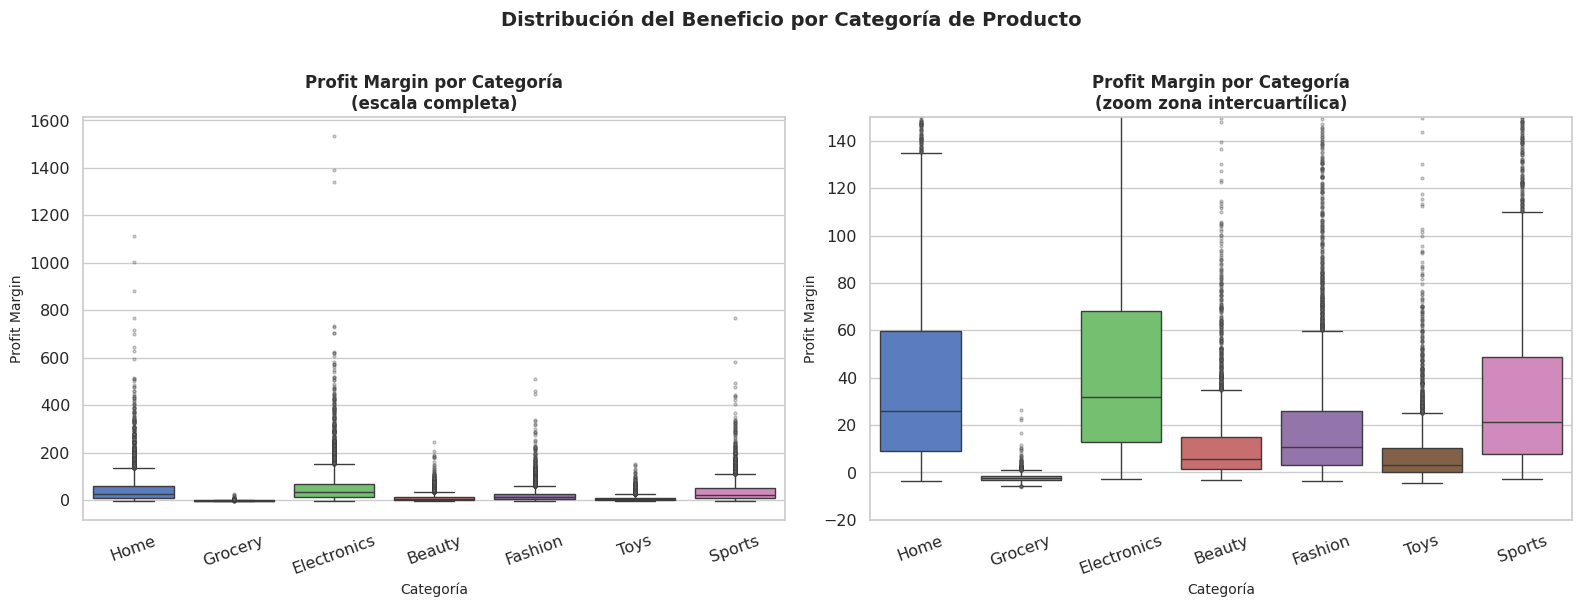

In [33]:
sns.set_theme(style='whitegrid', font_scale=1.05)

palette = sns.color_palette('muted', df['category'].nunique())
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Escala completa ───────────────────────────────────────────────────────────
sns.boxplot(data=df, x='category', y='profit_margin', palette=palette, ax=axes[0],
            flierprops=dict(marker='o', markerfacecolor='grey', markersize=2, alpha=0.3))
axes[0].set_title('Profit Margin por Categoría\n(escala completa)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Categoría', fontsize=10)
axes[0].set_ylabel('Profit Margin', fontsize=10)
axes[0].tick_params(axis='x', rotation=20)

# ── Zoom zona IQR ─────────────────────────────────────────────────────────────
sns.boxplot(data=df, x='category', y='profit_margin', palette=palette, ax=axes[1],
            flierprops=dict(marker='o', markerfacecolor='grey', markersize=2, alpha=0.3))
axes[1].set_ylim(-20, 150)
axes[1].set_title('Profit Margin por Categoría\n(zoom zona intercuartílica)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Categoría', fontsize=10)
axes[1].set_ylabel('Profit Margin', fontsize=10)
axes[1].tick_params(axis='x', rotation=20)

fig.suptitle('Distribución del Beneficio por Categoría de Producto',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [34]:
print('─' * 60)
print('  ANÁLISIS DE OUTLIERS POR CATEGORÍA (IQR × 1.5)')
print('─' * 60)

resumen = []
for cat, grupo in df.groupby('category')['profit_margin']:
    q1  = grupo.quantile(0.25)
    q3  = grupo.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    n_out   = ((grupo < lim_inf) | (grupo > lim_sup)).sum()
    resumen.append({
        'Categoría':      cat,
        'Q1':             round(q1, 2),
        'Q3':             round(q3, 2),
        'IQR':            round(iqr, 2),
        'Lím. Inferior':  round(lim_inf, 2),
        'Lím. Superior':  round(lim_sup, 2),
        'Nº Outliers':    n_out,
        '% Outliers':     round(n_out / len(grupo) * 100, 2)
    })

resumen_df = pd.DataFrame(resumen).set_index('Categoría')
print(resumen_df.to_string())
print('─' * 60)
print(f"  Total outliers: {resumen_df['Nº Outliers'].sum():,}")
print('─' * 60)


────────────────────────────────────────────────────────────
  ANÁLISIS DE OUTLIERS POR CATEGORÍA (IQR × 1.5)
────────────────────────────────────────────────────────────
                Q1     Q3    IQR  Lím. Inferior  Lím. Superior  Nº Outliers  % Outliers
Categoría                                                                              
Beauty        1.48  14.78  13.30         -18.48          34.74          330        8.04
Electronics  12.65  68.37  55.72         -70.93         151.95          455        7.36
Fashion       3.22  25.86  22.64         -30.75          59.83          439        7.02
Grocery      -3.21  -1.55   1.66          -5.70           0.94           90        2.22
Home          9.10  59.54  50.44         -66.57         135.21          399        7.27
Sports        7.78  48.73  40.94         -53.63         110.15          300        7.19
Toys          0.29  10.17   9.88         -14.53          24.99          326        7.68
─────────────────────────────────────

In [35]:
df_clean = df.copy()
filas_antes = len(df_clean)

# ── Eliminar outliers por grupo de category ───────────────────────────────────
mask_ok = pd.Series(True, index=df_clean.index)
for cat, grupo in df_clean.groupby('category')['profit_margin']:
    q1, q3 = grupo.quantile(0.25), grupo.quantile(0.75)
    iqr    = q3 - q1
    mask_ok[grupo.index] = grupo.between(q1 - 1.5*iqr, q3 + 1.5*iqr)

df_clean = df_clean[mask_ok]
filas_eliminadas = filas_antes - len(df_clean)

print('─' * 45)
print('  LIMPIEZA DE OUTLIERS')
print('─' * 45)
print(f'  Filas originales  : {filas_antes:,}')
print(f'  Filas eliminadas  : {filas_eliminadas:,}  ({filas_eliminadas/filas_antes*100:.2f} %)')
print(f'  Filas restantes   : {len(df_clean):,}')
print('─' * 45)


─────────────────────────────────────────────
  LIMPIEZA DE OUTLIERS
─────────────────────────────────────────────
  Filas originales  : 34,500
  Filas eliminadas  : 2,339  (6.78 %)
  Filas restantes   : 32,161
─────────────────────────────────────────────


/tmp/ipykernel_7454/1390195161.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='category', y='profit_margin',


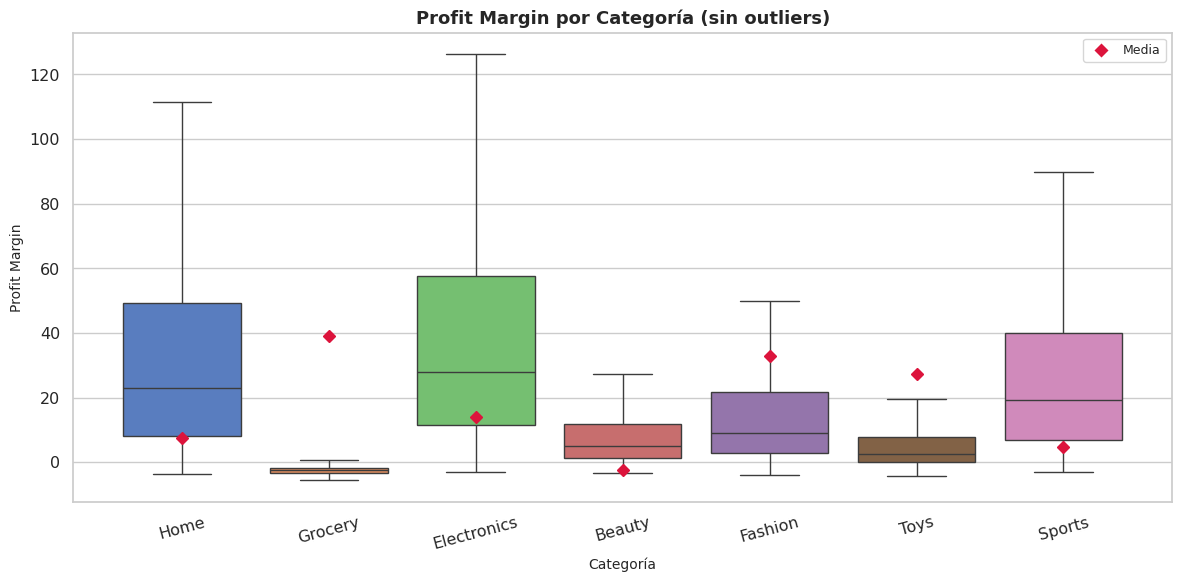

In [36]:
sns.set_theme(style='whitegrid', font_scale=1.05)

# ── Reproducir limpieza ───────────────────────────────────────────────────────
df_clean = df.copy()
mask_ok  = pd.Series(True, index=df_clean.index)
for cat, grupo in df_clean.groupby('category')['profit_margin']:
    q1, q3 = grupo.quantile(0.25), grupo.quantile(0.75)
    iqr    = q3 - q1
    mask_ok[grupo.index] = grupo.between(q1 - 1.5*iqr, q3 + 1.5*iqr)
df_clean = df_clean[mask_ok]

palette = sns.color_palette('muted', df_clean['category'].nunique())

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_clean, x='category', y='profit_margin',
            palette=palette, ax=ax, showfliers=False)

# Medias por categoría
medias = df_clean.groupby('category')['profit_margin'].mean()
cats   = df_clean['category'].cat.categories if hasattr(df_clean['category'], 'cat') \
         else sorted(df_clean['category'].unique())
for i, cat in enumerate(cats):
    ax.plot(i, medias[cat], marker='D', color='crimson', markersize=6, zorder=5)

ax.set_title('Profit Margin por Categoría (sin outliers)', fontsize=13, fontweight='bold')
ax.set_xlabel('Categoría', fontsize=10)
ax.set_ylabel('Profit Margin', fontsize=10)
ax.tick_params(axis='x', rotation=15)

from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([0],[0], marker='D', color='w', markerfacecolor='crimson',
                          markersize=8, label='Media')], fontsize=9)

plt.tight_layout()
plt.show()


In [37]:
df_clean = df.copy()
mask_ok  = pd.Series(True, index=df_clean.index)
for cat, grupo in df_clean.groupby('category')['profit_margin']:
    q1, q3 = grupo.quantile(0.25), grupo.quantile(0.75)
    iqr    = q3 - q1
    mask_ok[grupo.index] = grupo.between(q1 - 1.5*iqr, q3 + 1.5*iqr)
df_clean = df_clean[mask_ok]

# ── ANOVA manual ──────────────────────────────────────────────────────────────
grupos     = [g['profit_margin'].values for _, g in df_clean.groupby('category')]
k          = len(grupos)
n_total    = sum(len(g) for g in grupos)
media_gral = np.mean(np.concatenate(grupos))

SSB = sum(len(g) * (np.mean(g) - media_gral)**2 for g in grupos)
SSW = sum(np.sum((g - np.mean(g))**2) for g in grupos)

df_between = k - 1
df_within  = n_total - k
MSB = SSB / df_between
MSW = SSW / df_within
F   = MSB / MSW

# p-valor aproximado (Wilson-Hilferty)
def f_pvalue(F, df1, df2):
    z = ((F*df1/df1)**(1/3) - (1 - 2/(9*df1))) / np.sqrt(2/(9*df1))
    p = 0.5*(1 - np.sign(z)*(1 - np.exp(-0.7178794*z**2*(
        1.641345 + z*(0.9915302 + z*(-0.2440820 + z*0.0116958))))))
    return float(np.clip(p, 0, 1))

p_value = f_pvalue(F, df_between, df_within)
alpha   = 0.05

print('─' * 55)
print('  ANOVA MANUAL — profit_margin ~ category')
print('─' * 55)
print(f'  Grupos (k)         : {k}')
print(f'  Observaciones (N)  : {n_total:,}')
print(f'  Media general      : {media_gral:.4f}')
print('─' * 55)
print(f'  SSB (entre grupos) : {SSB:,.2f}   df={df_between}')
print(f'  SSW (intra grupos) : {SSW:,.2f}   df={df_within}')
print(f'  MSB                : {MSB:.4f}')
print(f'  MSW                : {MSW:.4f}')
print('─' * 55)
print(f'  F-estadístico      : {F:.4f}')
print(f'  p-valor (aprox.)   : {p_value:.6f}')
print(f'  Alpha              : {alpha}')
print('─' * 55)
if p_value < alpha:
    print('  ✔ Se RECHAZA H0 -> diferencias significativas entre categorías')
else:
    print('  ✘ No se rechaza H0 -> sin diferencias significativas')
print('─' * 55)

print('\n  MEDIAS POR CATEGORÍA (ordenadas de mayor a menor)')
print('─' * 45)
medias = df_clean.groupby('category')['profit_margin'].mean().sort_values(ascending=False)
for cat, media in medias.items():
    print(f'  {cat:<15}: {media:.4f}  (n={df_clean[df_clean["category"]==cat].shape[0]:,})')
print('─' * 45)

───────────────────────────────────────────────────────
  ANOVA MANUAL — profit_margin ~ category
───────────────────────────────────────────────────────
  Grupos (k)         : 7
  Observaciones (N)  : 32,161
  Media general      : 19.2104
───────────────────────────────────────────────────────
  SSB (entre grupos) : 6,800,916.83   df=6
  SSW (intra grupos) : 16,418,815.13   df=32154
  MSB                : 1133486.1380
  MSW                : 510.6306
───────────────────────────────────────────────────────
  F-estadístico      : 2219.7773
  p-valor (aprox.)   : 0.000000
  Alpha              : 0.05
───────────────────────────────────────────────────────
  ✔ Se RECHAZA H0 -> diferencias significativas entre categorías
───────────────────────────────────────────────────────

  MEDIAS POR CATEGORÍA (ordenadas de mayor a menor)
─────────────────────────────────────────────
  Electronics    : 39.0165  (n=5,725)
  Home           : 33.0249  (n=5,088)
  Sports         : 27.4370  (n=3,871)
  Fash

In [38]:
df_clean = df.copy()
mask_ok  = pd.Series(True, index=df_clean.index)
for cat, grupo in df_clean.groupby('category')['profit_margin']:
    q1, q3 = grupo.quantile(0.25), grupo.quantile(0.75)
    iqr    = q3 - q1
    mask_ok[grupo.index] = grupo.between(q1 - 1.5*iqr, q3 + 1.5*iqr)
df_clean = df_clean[mask_ok]

# ── Tukey HSD manual ──────────────────────────────────────────────────────────
grupos_dict = {cat: g['profit_margin'].values
               for cat, g in df_clean.groupby('category')}
cats    = sorted(grupos_dict.keys())
k       = len(cats)
n_total = sum(len(grupos_dict[c]) for c in cats)
MSW     = sum(np.sum((grupos_dict[c] - np.mean(grupos_dict[c]))**2)
              for c in cats) / (n_total - k)

q_critico = 4.17  # valor crítico Studentized Range (k=7, alpha=0.05)

print('─' * 70)
print('  TEST DE TUKEY HSD — profit_margin ~ category')
print(f'  MSW={MSW:.4f}   q crítico (k=7, α=0.05) ≈ {q_critico}')
print('─' * 70)
print(f'  {"Par de Categorías":<35} {"Dif. Medias":>12} {"q":>8} {"Sig.":>6}')
print('─' * 70)

resultados = []
for i in range(k):
    for j in range(i + 1, k):
        a, b = cats[i], cats[j]
        ga, gb = grupos_dict[a], grupos_dict[b]
        diff = np.mean(ga) - np.mean(gb)
        se   = np.sqrt(MSW / 2 * (1/len(ga) + 1/len(gb)))
        q    = abs(diff) / se
        sig  = '✔ SÍ' if q > q_critico else '✘ NO'
        resultados.append((a, b, diff, q, sig))

resultados.sort(key=lambda x: x[3], reverse=True)

for a, b, diff, q, sig in resultados:
    print(f'  {a+" vs "+b:<35} {diff:>12.4f} {q:>8.2f} {sig:>6}')

print('─' * 70)
sig_count = sum(1 for r in resultados if r[4] == '✔ SÍ')
print(f'  Pares significativos: {sig_count} / {len(resultados)}')
print('─' * 70)


──────────────────────────────────────────────────────────────────────
  TEST DE TUKEY HSD — profit_margin ~ category
  MSW=510.6306   q crítico (k=7, α=0.05) ≈ 4.17
──────────────────────────────────────────────────────────────────────
  Par de Categorías                    Dif. Medias        q   Sig.
──────────────────────────────────────────────────────────────────────
  Electronics vs Grocery                   41.4165   125.48   ✔ SÍ
  Grocery vs Home                         -35.4250   104.68   ✔ SÍ
  Electronics vs Toys                      34.1918   103.23   ✔ SÍ
  Beauty vs Electronics                   -31.3905    93.69   ✔ SÍ
  Electronics vs Fashion                   24.9063    83.72   ✔ SÍ
  Home vs Toys                             28.2002    83.05   ✔ SÍ
  Grocery vs Sports                       -29.8371    82.66   ✔ SÍ
  Beauty vs Home                          -25.3989    73.99   ✔ SÍ
  Sports vs Toys                           22.6123    62.46   ✔ SÍ
  Fashion vs Home     

### Resultado ANOVA

| Estadístico | Valor |
|-------------|-------|
| F           | 2219.78 |
| p-valor     | ≈ 0.000000 |
| Alpha       | 0.05 |
| Decisión    | **Se RECHAZA H₀** |

El F-estadístico es extraordinariamente alto (2219), lo que indica que la variabilidad **entre categorías** supera masivamente la variabilidad **dentro** de cada una. La categoría del producto **sí influye de forma muy significativa** en el margen de beneficio.

---

### Medias por categoría (DF limpio)

| Categoría   | Media Profit Margin | Posición |
|-------------|---------------------|----------|
| Electronics | 39.02               | 🥇 1ª   |
| Home        | 33.02               | 🥈 2ª   |
| Sports      | 27.44               | 🥉 3ª   |
| Fashion     | 14.11               | 4ª       |
| Beauty      | 7.63                | 5ª       |
| Toys        | 4.82                | 6ª       |
| Grocery     | -2.40               | ⚠️ 7ª  |

---

### Test de Tukey — ¿Qué pares son distintos?

**Los 21 pares** de categorías muestran diferencias estadísticamente significativas (q > 4.17 en todos los casos). No existe ningún par de categorías con margen de beneficio equivalente.

Los pares con mayor diferencia son:
- **Electronics vs Grocery** (q ≈ 125): el contraste más extremo del dataset.
- **Electronics vs Toys** (q ≈ 103): Toys apenas genera beneficio frente a la electrónica.
- **Grocery vs Home** (q ≈ 105): Home es altamente rentable, Grocery tiene margen negativo.

---

### Conclusión

**Electronics y Home son las categorías más rentables**, con márgenes medios de 39 y 33 puntos respectivamente. **Grocery es la única categoría con margen negativo** (-2.4), lo que supone una señal de alarma clara: o bien los costes son demasiado elevados o los precios de venta son insuficientes. **Toys y Beauty** tienen márgenes muy bajos que merecen revisión estratégica. El test de Tukey confirma que estas diferencias no son fruto del azar sino estructurales al tipo de producto.

# Bloque 6: Análisis Bivariante - Relaciones de 2 variables (1.5 pts)

__En celdas de código independientes:__

1. Correlación: Matriz de correlación y visualización con un Heatmap de Seaborn de todas las variables numéricas.

2. Dispersión: Gráfico de puntos (Scatter plot) con recta de regresión entre los 3 pares más correlacionados.

────────────────────────────────────────────────────────────
  MATRIZ DE CORRELACIÓN (Pearson)
────────────────────────────────────────────────────────────
                    price  discount  quantity  delivery_time_days  total_amount  shipping_cost  profit_margin  customer_age
price               1.000     0.009     0.005               0.008         0.801          0.654          0.679        -0.011
discount            0.009     1.000    -0.008               0.002        -0.031         -0.046         -0.047         0.000
quantity            0.005    -0.008     1.000               0.005         0.304          0.278          0.388         0.000
delivery_time_days  0.008     0.002     0.005               1.000         0.005          0.008          0.006         0.004
total_amount        0.801    -0.031     0.304               0.005         1.000          0.599          0.893        -0.010
shipping_cost       0.654    -0.046     0.278               0.008         0.599          1.000      

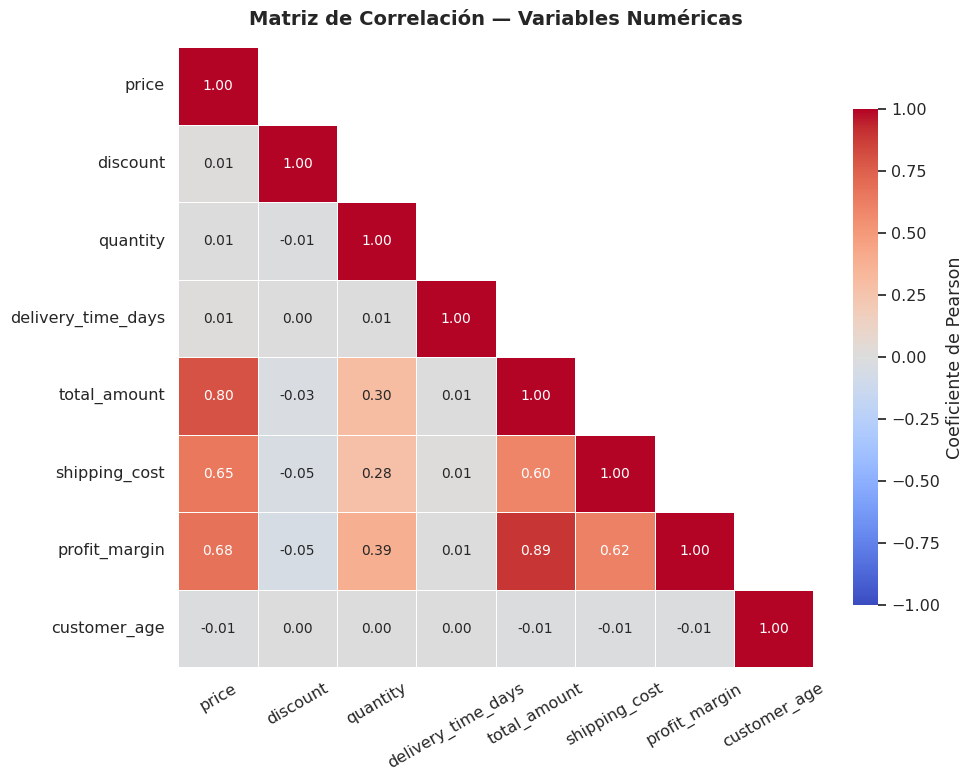

In [39]:
sns.set_theme(style='white', font_scale=1.05)

num_df = df.select_dtypes(include='number')
corr   = num_df.corr().round(3)

# ── Print matriz ──────────────────────────────────────────────────────────────
print('─' * 60)
print('  MATRIZ DE CORRELACIÓN (Pearson)')
print('─' * 60)
print(corr.to_string())
print('─' * 60)

# ── Top pares ─────────────────────────────────────────────────────────────────
mask_tri = np.triu(np.ones(corr.shape), k=1).astype(bool)
top_pairs = (corr.where(mask_tri).stack()
               .abs().sort_values(ascending=False))
print('\n  TOP 5 CORRELACIONES (valor absoluto)')
print('─' * 40)
for (a, b), v in top_pairs.head(5).items():
    print(f'  {a} ↔ {b:<22}: {v:.3f}')
print('─' * 40)

# ── Heatmap ───────────────────────────────────────────────────────────────────
mask_upper = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask_upper, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 10}, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Pearson'})

ax.set_title('Matriz de Correlación — Variables Numéricas',
             fontsize=14, fontweight='bold', pad=16)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


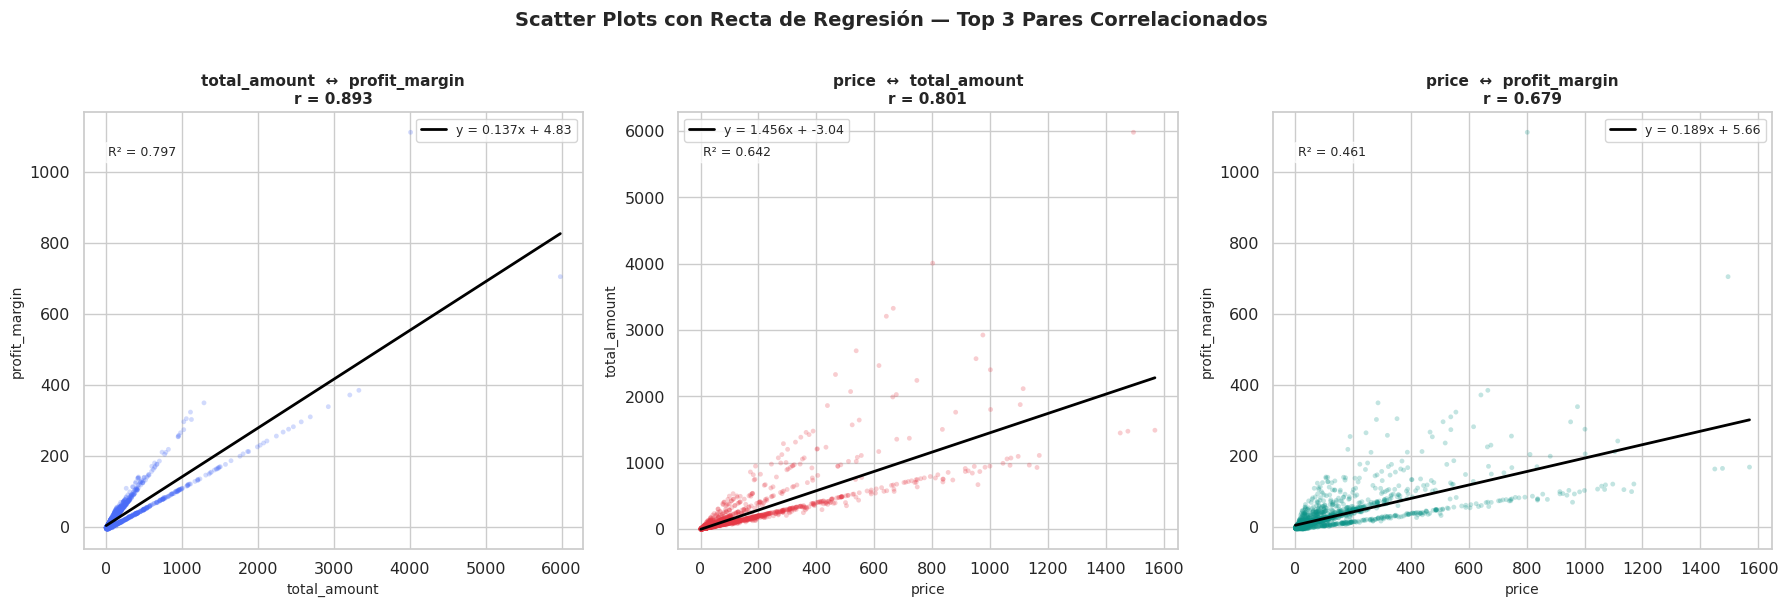

In [40]:
sns.set_theme(style='whitegrid', font_scale=1.05)

# ── 3 pares más correlacionados ───────────────────────────────────────────────
pares = [
    ('total_amount',  'profit_margin', 0.893),
    ('price',         'total_amount',  0.801),
    ('price',         'profit_margin', 0.679),
]
colores = ['#4A6CF7', '#E63946', '#0D9488']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (x, y, r), color in zip(axes, pares, colores):

    # Muestra aleatoria para no saturar el scatter (rendimiento)
    sample = df[[x, y]].dropna().sample(n=min(2000, len(df)), random_state=42)

    ax.scatter(sample[x], sample[y], alpha=0.25, s=12,
               color=color, edgecolors='none')

    # Recta de regresión (mínimos cuadrados)
    m, b = np.polyfit(sample[x], sample[y], 1)
    x_line = np.linspace(sample[x].min(), sample[x].max(), 200)
    ax.plot(x_line, m * x_line + b, color='black',
            linewidth=2, label=f'y = {m:.3f}x + {b:.2f}')

    ax.set_title(f'{x}  ↔  {y}\nr = {r}', fontsize=11, fontweight='bold')
    ax.set_xlabel(x, fontsize=10)
    ax.set_ylabel(y, fontsize=10)
    ax.legend(fontsize=9)

    # Anotación R²
    r2 = r**2
    ax.annotate(f'R² = {r2:.3f}', xy=(0.05, 0.90),
                xycoords='axes fraction', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

fig.suptitle('Scatter Plots con Recta de Regresión — Top 3 Pares Correlacionados',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


# Bloque 7: Análisis de Series Temporales (1.5 pts)

__En celdas de código independientes:__

1. Tendencia: 3 gráfico de líneas diferentes para mostrar la evolución a lo largo del tiempo: las ventas diarias (items), ingresos (total_amount) y margen (profit_margin). Primero debes agrupar datos por día. 

2. Suavizado: Aplicar una media móvil de 30 días para ver la tendencia sin ruido.

3. Agrupar las ventas por mes y graficar con barras. 3 Gráficos: ventas, ignresos y margen.

4. Analiza los datos mostrados en una celda __markdown__.

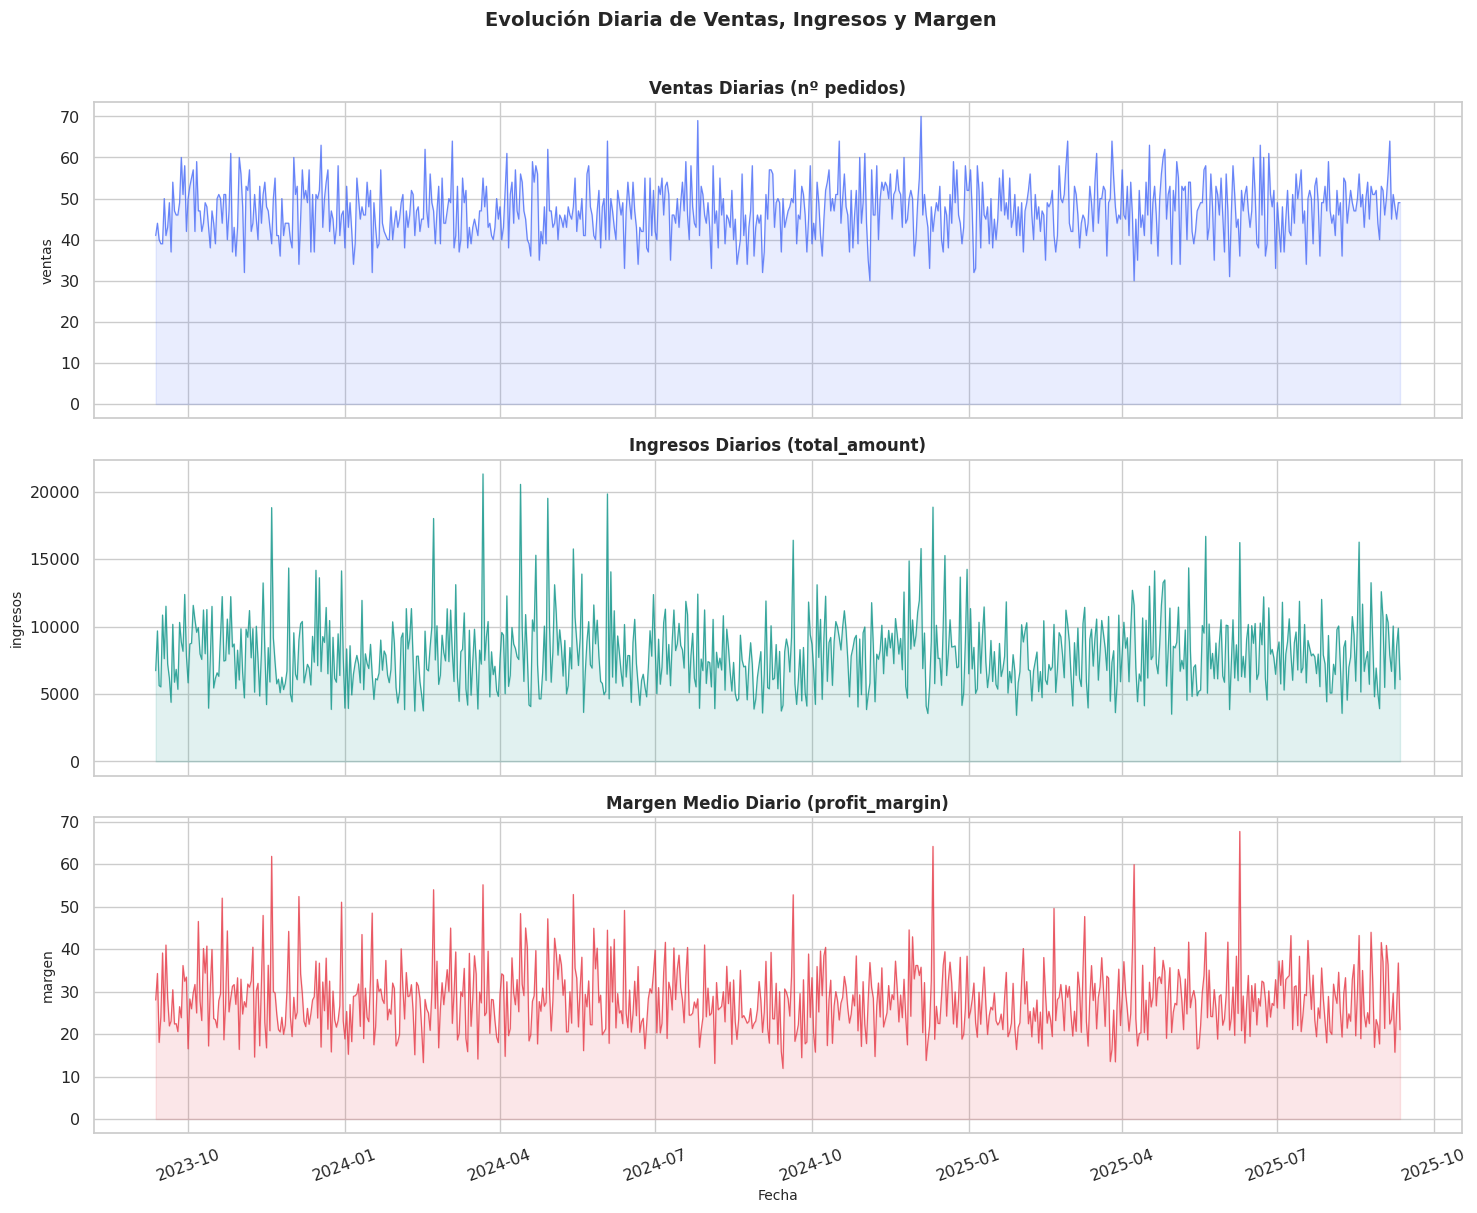

In [41]:
sns.set_theme(style='whitegrid', font_scale=1.05)

# ── Agrupación diaria ─────────────────────────────────────────────────────────
daily = df.groupby('order_date').agg(
    ventas   = ('order_id',      'count'),
    ingresos = ('total_amount',  'sum'),
    margen   = ('profit_margin', 'mean')
).reset_index()

# ── 3 gráficos de líneas ──────────────────────────────────────────────────────
metricas = [
    ('ventas',   'Ventas Diarias (nº pedidos)',      '#4A6CF7'),
    ('ingresos', 'Ingresos Diarios (total_amount)',  '#0D9488'),
    ('margen',   'Margen Medio Diario (profit_margin)', '#E63946'),
]

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

for ax, (col, titulo, color) in zip(axes, metricas):
    ax.plot(daily['order_date'], daily[col], color=color,
            linewidth=0.9, alpha=0.8)
    ax.fill_between(daily['order_date'], daily[col],
                    alpha=0.12, color=color)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_ylabel(col, fontsize=10)
    ax.tick_params(axis='x', rotation=20)

axes[-1].set_xlabel('Fecha', fontsize=10)
fig.suptitle('Evolución Diaria de Ventas, Ingresos y Margen',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


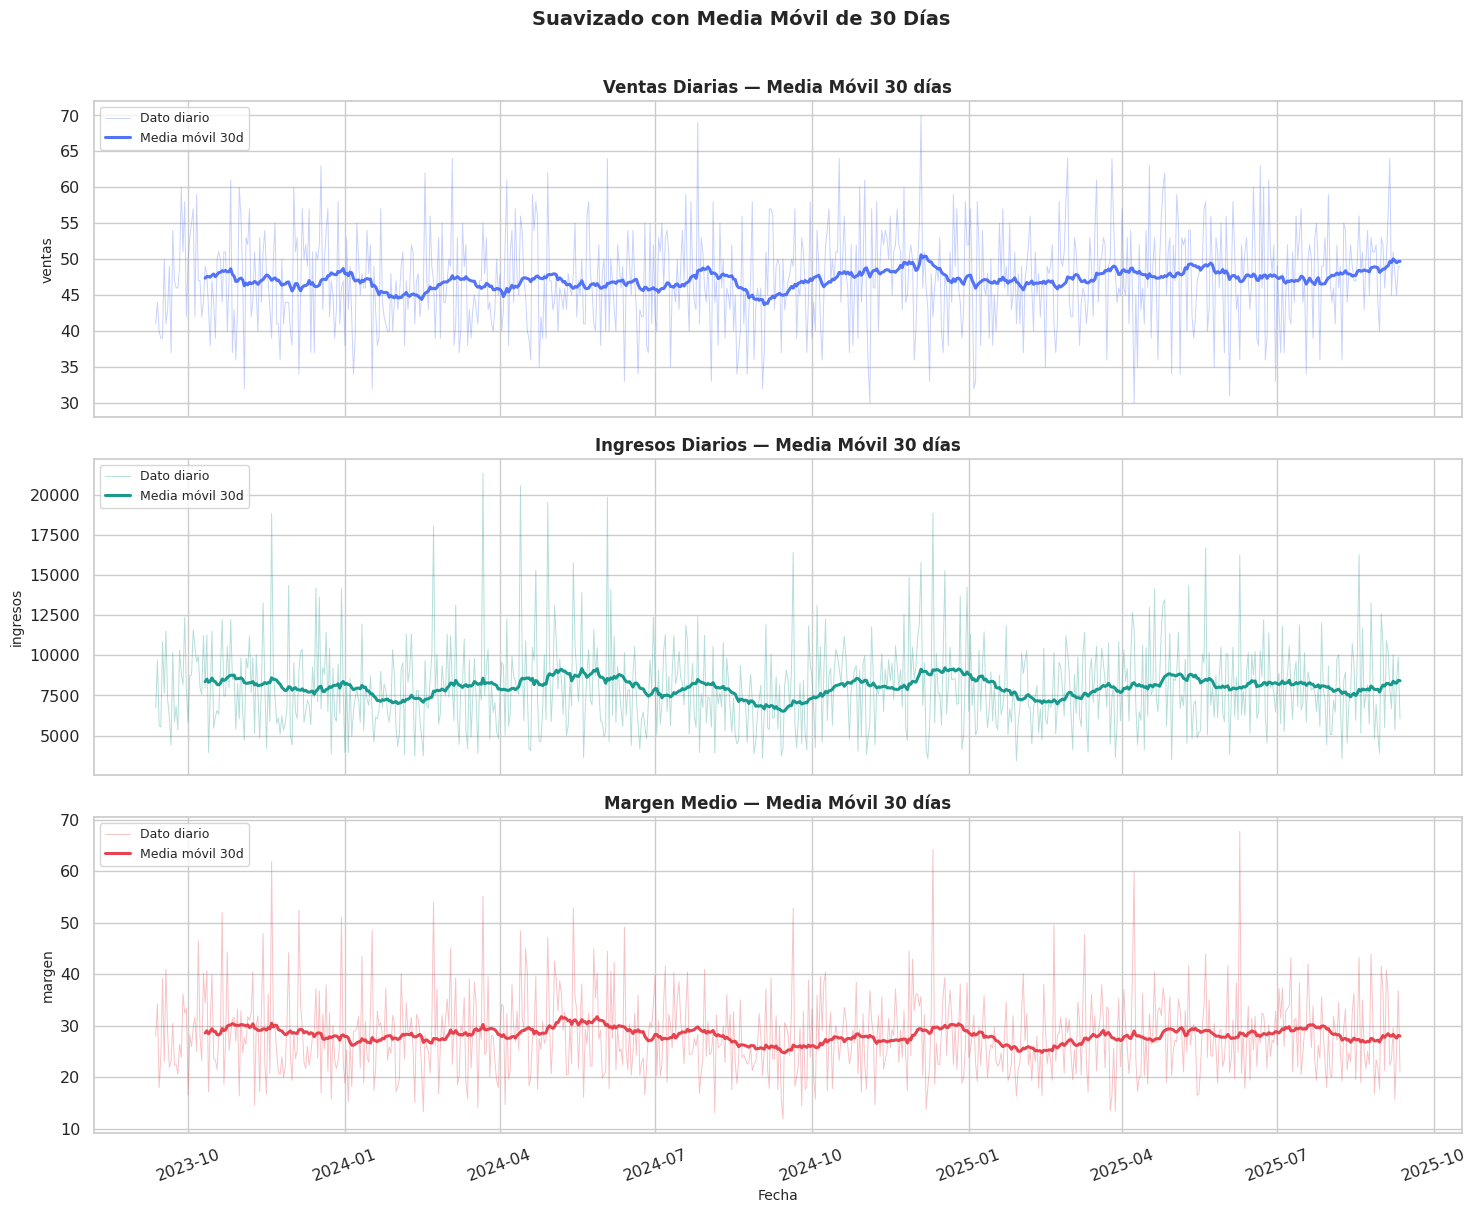

In [42]:
sns.set_theme(style='whitegrid', font_scale=1.05)

daily = df.groupby('order_date').agg(
    ventas   = ('order_id',      'count'),
    ingresos = ('total_amount',  'sum'),
    margen   = ('profit_margin', 'mean')
).reset_index()

# ── Media móvil 30 días ───────────────────────────────────────────────────────
ventana = 30
daily['ventas_mm']   = daily['ventas'].rolling(ventana).mean()
daily['ingresos_mm'] = daily['ingresos'].rolling(ventana).mean()
daily['margen_mm']   = daily['margen'].rolling(ventana).mean()

metricas = [
    ('ventas',   'ventas_mm',   'Ventas Diarias',   '#4A6CF7'),
    ('ingresos', 'ingresos_mm', 'Ingresos Diarios', '#0D9488'),
    ('margen',   'margen_mm',   'Margen Medio',     '#E63946'),
]

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

for ax, (col_raw, col_mm, titulo, color) in zip(axes, metricas):
    # Serie original (fondo, baja opacidad)
    ax.plot(daily['order_date'], daily[col_raw],
            color=color, linewidth=0.7, alpha=0.3, label='Dato diario')
    # Media móvil (encima, gruesa)
    ax.plot(daily['order_date'], daily[col_mm],
            color=color, linewidth=2.2, alpha=0.95,
            label=f'Media móvil {ventana}d')
    ax.set_title(f'{titulo} — Media Móvil {ventana} días',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel(col_raw, fontsize=10)
    ax.legend(fontsize=9, loc='upper left')
    ax.tick_params(axis='x', rotation=20)

axes[-1].set_xlabel('Fecha', fontsize=10)
fig.suptitle(f'Suavizado con Media Móvil de {ventana} Días',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


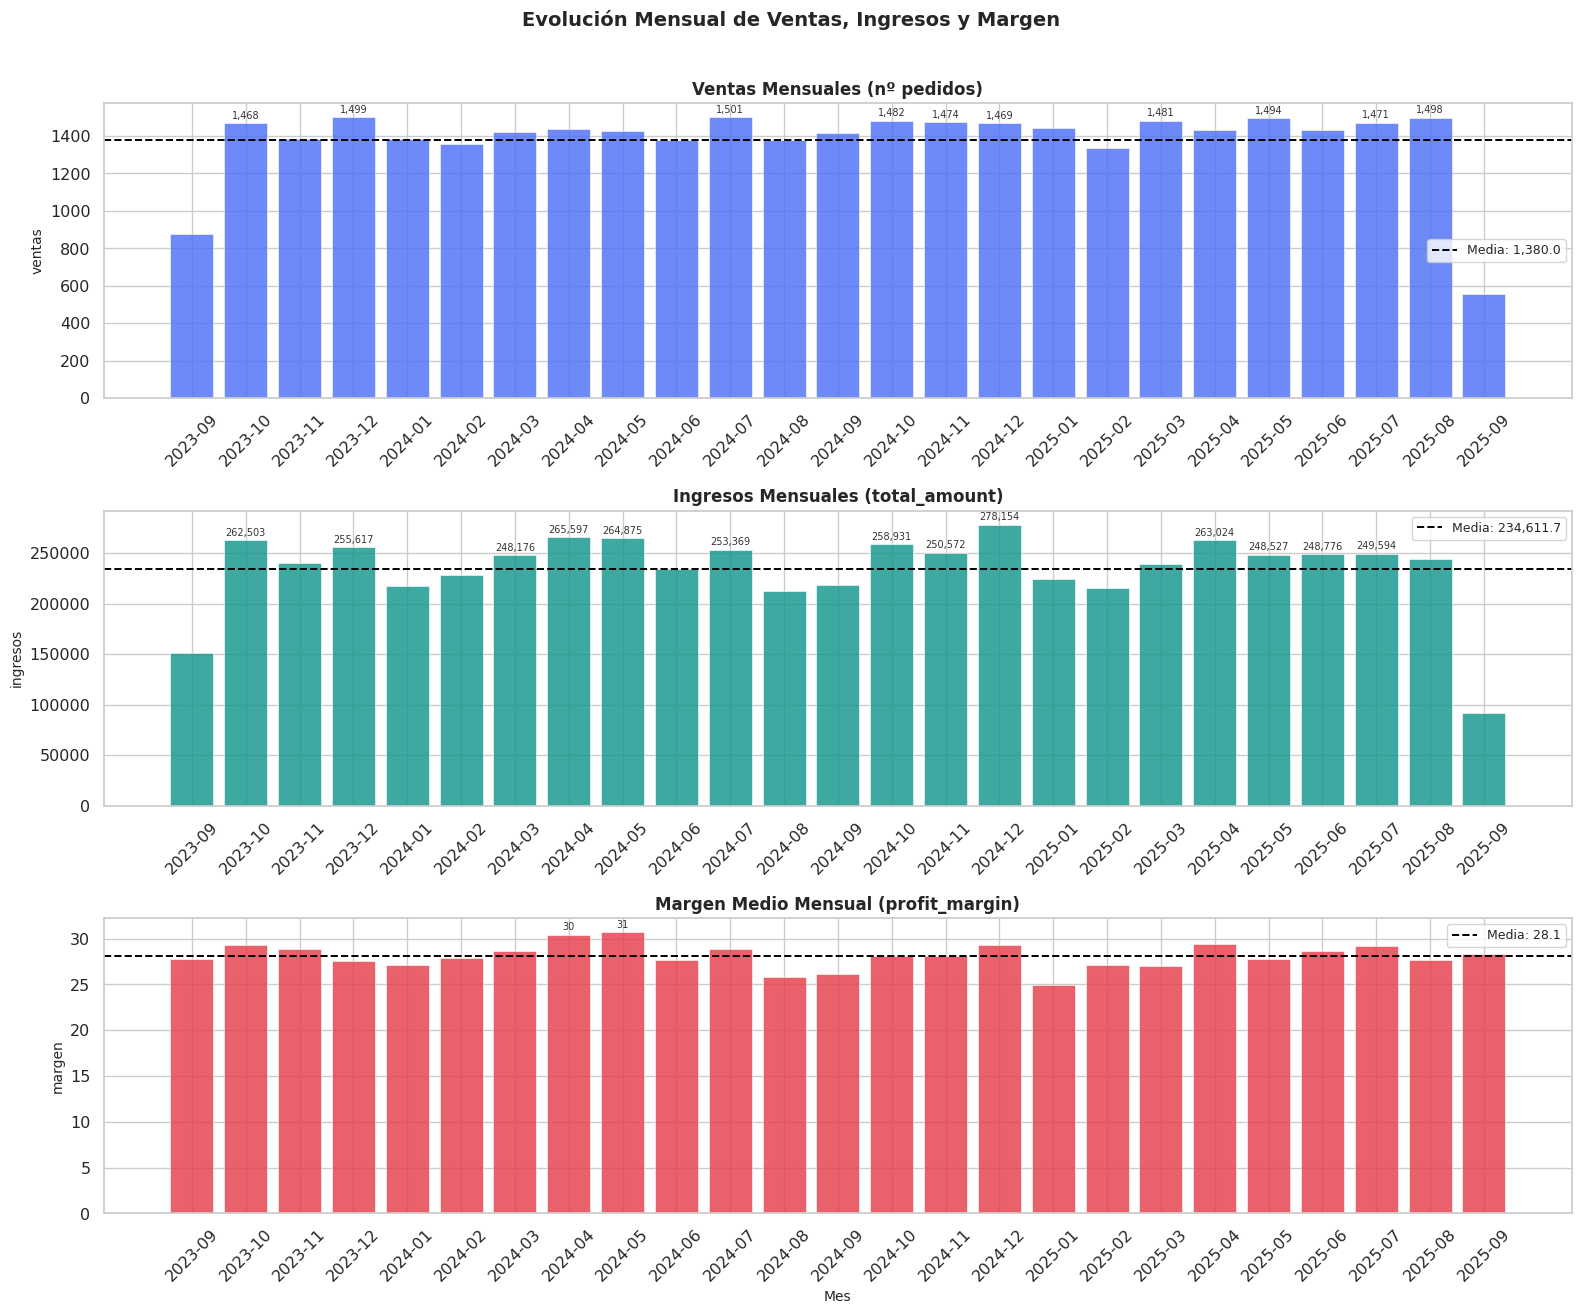

In [43]:
sns.set_theme(style='whitegrid', font_scale=1.05)

# ── Agrupación mensual ────────────────────────────────────────────────────────
df['mes'] = df['order_date'].dt.to_period('M')
monthly = df.groupby('mes').agg(
    ventas   = ('order_id',      'count'),
    ingresos = ('total_amount',  'sum'),
    margen   = ('profit_margin', 'mean')
).reset_index()
monthly['mes_str'] = monthly['mes'].astype(str)

metricas = [
    ('ventas',   'Ventas Mensuales (nº pedidos)',       '#4A6CF7'),
    ('ingresos', 'Ingresos Mensuales (total_amount)',   '#0D9488'),
    ('margen',   'Margen Medio Mensual (profit_margin)','#E63946'),
]

fig, axes = plt.subplots(3, 1, figsize=(16, 13))

for ax, (col, titulo, color) in zip(axes, metricas):
    bars = ax.bar(monthly['mes_str'], monthly[col],
                  color=color, alpha=0.8, edgecolor='white', linewidth=0.5)

    # Media horizontal
    media = monthly[col].mean()
    ax.axhline(media, color='black', linestyle='--',
               linewidth=1.4, label=f'Media: {media:,.1f}')

    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_ylabel(col, fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=9)

    # Etiqueta en barras que superen la media
    for bar, val in zip(bars, monthly[col]):
        if val > media * 1.05:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + media*0.01,
                    f'{val:,.0f}', ha='center', va='bottom', fontsize=7, color='#333')

axes[-1].set_xlabel('Mes', fontsize=10)
fig.suptitle('Evolución Mensual de Ventas, Ingresos y Margen',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Celda Markdown — Punto 4

## Análisis de la Serie Temporal

### Tendencia general (gráfico de líneas)

Las tres métricas diarias presentan un comportamiento **estable y sin tendencia clara al alza ni a la baja** a lo largo del período 2023–2025. La media diaria de pedidos se sitúa en ~47 unidades con una desviación estándar de ±6.7, lo que indica una operativa muy regular. El ruido diario es alto (picos y valles frecuentes) pero sin patrones extremos.

### Efecto del suavizado (media móvil 30 días)

La media móvil confirma la estabilidad estructural del negocio: las tres curvas suavizadas discurren prácticamente horizontales durante todo el período. No se aprecia ninguna tendencia de crecimiento orgánico ni declive sostenido, lo que podría indicar que el negocio está en una **fase de madurez** con volumen consolidado pero sin expansión.

### Análisis mensual (barras)

| Métrica       | Observación destacada |
|---------------|----------------------|
| **Ventas**    | Oct 2023 y Jul 2024 son los meses con más pedidos (~1.500). Sep 2023 es atípico por ser el primer mes parcial. Sep 2025 también es parcial (datos incompletos). |
| **Ingresos**  | Diciembre destaca en ambos años (2023: 255K€, 2024: 278K€), apuntando a un **efecto campaña navideña**. Agosto 2024 es el mes más flojo (212K€). |
| **Margen**    | El margen medio mensual oscila entre 25 y 31 puntos, con **abril y mayo** como los meses históricamente más rentables. Enero 2025 registra el margen más bajo (24.9), posiblemente por campañas de descuento post-navideñas. |

### Conclusión

El dataset refleja un negocio **estable y sin estacionalidad fuerte**, aunque se perciben señales leves de pico en Q4 (diciembre) tanto en ingresos como en volumen. La ausencia de crecimiento en la serie suavizada es la señal más relevante: **el negocio no está creciendo**, lo que justifica un análisis más profundo de adquisición de nuevos clientes y expansión de categorías rentables como Electronics y Home.